
# Advanced Agricultural Price Analysis

Includes:
- Time Series Forecasting (ARIMA)
- Machine Learning Models (Random Forest)
- Visualization (Matplotlib)


In [19]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import numpy as np # Added for df_2026 definition
import re # Added for clean_commodity_name function

# --- Start of code copied from cell BBhKyt_aoIv8 to define df_2026 ---
data = [
# Commodity_Group, Commodity, MSP, P26, P25, P24, A26, A25, A24

["Cereals","Bajra (Pearl Millet/Cumbu)",2775,2449.91,2400.41,2417.13,662.52,1681.02,1335.59],
["Cereals","Barley (Jau)",2150,1846.68,1876.95,1986.74,6558.32,4752.65,3233.67],
["Cereals","Jowar (Sorghum)",3699,3575.12,4303.34,4182.98,354.27,282.93,617.46],
["Cereals","Maize",2400,1669.08,1690.88,1713.27,22476.68,19732.91,19077.82],
["Cereals","Paddy (Common)",2369,2591.09,2804.66,2845.51,17170.54,25834.06,20329.07],
["Cereals","Ragi (Finger Millet)",4886,3070.20,3459.60,3196.24,422.70,664.60,275.10],
["Cereals","Wheat",2585,2331.81,2365.36,2364.07,71372.37,112105.91,94273.66],

["Fibre Crops","Cotton",7710,7921.41,7904.64,7562.40,2642.58,3143.43,3413.33],

["Oil Seeds","Copra",12100,16998.99,21157.12,23045.48,59.70,118.70,117.90],
["Oil Seeds","Groundnut",7263,7379.70,7325.89,6989.20,4339.72,4501.77,954.33],
["Oil Seeds","Mustard",6200,6346.32,6384.15,6396.71,23983.78,30985.89,23790.11],
["Oil Seeds","Niger Seed (Ramtil)",9537,np.nan,np.nan,9100.00,np.nan,np.nan,2.00],
["Oil Seeds","Safflower",6540,4491.73,5015.90,4913.66,67.60,35.50,8.70],
["Oil Seeds","Sesamum (Sesame/Gingelly/Til)",9846,13262.51,10092.62,9911.43,7.49,93.86,51.22],
["Oil Seeds","Soyabean",5328,5359.40,5363.19,5362.31,4574.87,10496.18,12037.54],
["Oil Seeds","Sunflower",7721,6958.50,6895.60,7117.24,721.20,1436.10,829.00],
["Oil Seeds","Sunflower Seed",6760,6051.00,np.nan,np.nan,5.00,np.nan,np.nan],

["Others","Sugarcane",285,np.nan,300.00,np.nan,np.nan,12.00,np.nan],

["Pulses","Arhar (Tur/Red Gram)",8000,7504.27,7692.12,7384.83,1037.83,1684.01,1648.22],
["Pulses","Bengal Gram (Gram)",5875,5271.68,5277.23,5262.58,8506.69,14551.94,11485.73],
["Pulses","Black Gram (Urd Beans)",7800,8514.24,8050.67,8302.73,239.20,349.92,376.46],
["Pulses","Green Gram (Moong)",8768,7963.94,7793.97,8017.64,460.64,817.79,637.49],
["Pulses","Lentil (Masur)",7000,6882.07,6639.07,6847.75,1232.31,2856.96,2237.34],

["Vegetables","Onion",np.nan,1243.57,1117.97,1128.16,4897.54,15507.64,16691.43],
["Vegetables","Potato",np.nan,682.92,688.68,773.56,10416.27,12448.86,15197.17],
["Vegetables","Tomato",np.nan,1301.34,1288.85,1337.98,2848.51,3320.35,3630.13],
]

columns = [
"Commodity_Group",
"Commodity",
"MSP_2026_27",
"Price_26Mar",
"Price_25Mar",
"Price_24Mar",
"Arrival_26Mar",
"Arrival_25Mar",
"Arrival_24Mar"
]

df_2026 = pd.DataFrame(data, columns=columns)

# Function to clean commodity names
def clean_commodity_name(name):
    return re.sub(r'\\s\\(.+\\)', '', name).strip()

df_2026["Commodity"] = df_2026["Commodity"].apply(clean_commodity_name)
# --- End of copied code ---

# Get user input for commodity and target year
target_crop = input("Enter the commodity name (e.g., Bajra, Wheat): ")
target_year_str = input("Enter the target year for prediction (e.g., 2027): ")

valid_year_input = False
try:
    target_year = int(target_year_str)
    valid_year_input = True
except ValueError:
    print("Invalid year entered. Please enter a valid integer year.")

if valid_year_input:
    # Filter df_2026 for the selected crop, ignoring case
    crop_data = df_2026[df_2026["Commodity"].str.lower() == target_crop.lower()]

    if crop_data.empty:
        print(f"Commodity '{target_crop}' not found in the dataset. Please check the commodity name in `df_2026`.")
    else:
        # Extract historical prices for the selected crop from df_2026
        # Assuming 'Price_24Mar', 'Price_25Mar', 'Price_26Mar' represent March prices for 2024, 2025, 2026.
        historical_prices = crop_data.iloc[0][["Price_24Mar", "Price_25Mar", "Price_26Mar"]]
        historical_prices = pd.to_numeric(historical_prices)

        # Create a time series with appropriate dates (assuming March data)
        dates = pd.to_datetime([f'{2024}-03-01', f'{2025}-03-01', f'{2026}-03-01'])
        series = pd.Series(historical_prices.values, index=dates)

        # Determine the number of steps to forecast
        # We have data up to 2026. If target_year is 2027, steps=1; if 2028, steps=2, etc.
        steps_to_forecast = target_year - 2026

        if steps_to_forecast <= 0:
            print(f"Prediction for {target_year} is not forecasting into the future based on available data up to 2026.")
        else:
            try:
                # Train ARIMA model with order (1,1,0) for consistency with previous usage
                model = ARIMA(series, order=(1,1,0))
                model_fit = model.fit()

                # Forecast for the specified number of steps
                forecast = model_fit.forecast(steps=steps_to_forecast)

                # Print the predicted price for the target year and crop
                print(f"\nPredicted price for {target_crop.capitalize()} in {target_year}: {forecast.iloc[-1]:.2f}")

            except Exception as e:
                print(f"An error occurred during forecasting for {target_crop.capitalize()}: {e}")
                print("Consider checking the data for this commodity or adjusting the ARIMA model order.")

Enter the commodity name (e.g., Bajra, Wheat): wheat
Enter the target year for prediction (e.g., 2027): 2029

Predicted price for Wheat in 2029: 2334.11


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-MAR will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-MAR will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-MAR will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA


In [3]:

data = {
"Commodity":["Bajra","Barley","Jowar","Maize","Paddy","Ragi","Wheat"],
"Price_24":[2417,1986,4182,1713,2845,3196,2364],
"Price_25":[2400,1876,4303,1690,2804,3459,2365],
"Price_26":[2449,1846,3575,1669,2591,3070,2331]
}
df = pd.DataFrame(data)
df


,Commodity,Price_24,Price_25,Price_26
0,Bajra,2417,2400,2449
1,Barley,1986,1876,1846
2,Jowar,4182,4303,3575
3,Maize,1713,1690,1669
4,Paddy,2845,2804,2591
5,Ragi,3196,3459,3070
6,Wheat,2364,2365,2331


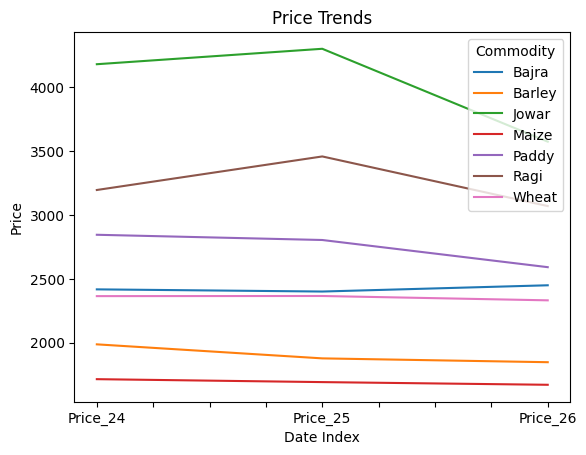

In [4]:

df.set_index("Commodity").T.plot()
plt.title("Price Trends")
plt.xlabel("Date Index")
plt.ylabel("Price")
plt.show()


In [5]:

X = df[["Price_24","Price_25"]]
y = df["Price_26"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))


RMSE: 261.47967645689016


In [6]:
series = pd.to_numeric(df.loc[0, ["Price_24","Price_25","Price_26"]])
series.index = pd.to_datetime(['2024-01-01', '2025-01-01', '2026-01-01'])
model = ARIMA(series, order=(1,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=1)

print("Next Day Forecast:", forecast)

Next Day Forecast: 2027-01-01    2418.021121
Freq: YS-JAN, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [7]:
import pandas as pd
import numpy as np

data = [
# Commodity_Group, Commodity, MSP, Kharif_Price, Kharif_Arrival, Rabi_Price, Rabi_Arrival

["Cereals","Bajra (Pearl Millet/Cumbu)",2775,2225.92,1683.80,np.nan,np.nan],
["Cereals","Barley (Jau)",1980,np.nan,np.nan,4156.02,60.20],
["Cereals","Jowar (Sorghum)",3699,3111.73,2049.90,np.nan,np.nan],
["Cereals","Maize",2400,1713.15,63380.13,np.nan,np.nan],
["Cereals","Paddy (Common)",2369,2556.35,102157.91,np.nan,np.nan],
["Cereals","Ragi (Finger Millet)",4886,3371.63,5100.50,np.nan,np.nan],
["Cereals","Wheat",2425,np.nan,np.nan,3102.97,8844.96],

["Fibre Crops","Cotton",7710,7806.64,60205.80,np.nan,np.nan],

["Oil Seeds","Copra",12100,np.nan,np.nan,17586.21,17549.10],
["Oil Seeds","Groundnut",7263,7629.59,4962.90,np.nan,np.nan],
["Oil Seeds","Mustard",5950,np.nan,np.nan,9071.58,243.30],
["Oil Seeds","Safflower",5940,np.nan,np.nan,4970.48,580.20],
["Oil Seeds","Sesamum (Sesame/Gingelly/Til)",9846,9824.69,48.20,np.nan,np.nan],
["Oil Seeds","Soyabean",5328,5330.59,1323.50,np.nan,np.nan],
["Oil Seeds","Sunflower",7721,7024.24,11362.10,np.nan,np.nan],

["Pulses","Arhar (Tur/Red Gram)",8000,7836.96,32108.90,np.nan,np.nan],
["Pulses","Bengal Gram (Gram)",5650,np.nan,np.nan,5463.29,15524.86],
["Pulses","Black Gram (Urd Beans)",7800,np.nan,np.nan,11457.20,588.30],
["Pulses","Green Gram (Moong)",8768,np.nan,np.nan,8981.95,2720.90],
]

columns = [
"Commodity_Group",
"Commodity",
"MSP_2025_26",
"Kharif_Price",
"Kharif_Arrival",
"Rabi_Price",
"Rabi_Arrival"
]

df_seasonal = pd.DataFrame(data, columns=columns)

# Display
print(df_seasonal.head())

# Basic info
print(df_seasonal.info())

  Commodity_Group                   Commodity  MSP_2025_26  Kharif_Price  \
0         Cereals  Bajra (Pearl Millet/Cumbu)         2775       2225.92   
1         Cereals                Barley (Jau)         1980           NaN   
2         Cereals             Jowar (Sorghum)         3699       3111.73   
3         Cereals                       Maize         2400       1713.15   
4         Cereals              Paddy (Common)         2369       2556.35   

   Kharif_Arrival  Rabi_Price  Rabi_Arrival  
0         1683.80         NaN           NaN  
1             NaN     4156.02          60.2  
2         2049.90         NaN           NaN  
3        63380.13         NaN           NaN  
4       102157.91         NaN           NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Commodity_Group  19 non-null     object 
 1   Commodity        19 no

In [8]:
import pandas as pd
import numpy as np
import re

data = [
# Commodity_Group, Commodity, MSP, P26, P25, P24, A26, A25, A24

["Cereals","Bajra (Pearl Millet/Cumbu)",2775,2449.91,2400.41,2417.13,662.52,1681.02,1335.59],
["Cereals","Barley (Jau)",2150,1846.68,1876.95,1986.74,6558.32,4752.65,3233.67],
["Cereals","Jowar (Sorghum)",3699,3575.12,4303.34,4182.98,354.27,282.93,617.46],
["Cereals","Maize",2400,1669.08,1690.88,1713.27,22476.68,19732.91,19077.82],
["Cereals","Paddy (Common)",2369,2591.09,2804.66,2845.51,17170.54,25834.06,20329.07],
["Cereals","Ragi (Finger Millet)",4886,3070.20,3459.60,3196.24,422.70,664.60,275.10],
["Cereals","Wheat",2585,2331.81,2365.36,2364.07,71372.37,112105.91,94273.66],

["Fibre Crops","Cotton",7710,7921.41,7904.64,7562.40,2642.58,3143.43,3413.33],

["Oil Seeds","Copra",12100,16998.99,21157.12,23045.48,59.70,118.70,117.90],
["Oil Seeds","Groundnut",7263,7379.70,7325.89,6989.20,4339.72,4501.77,954.33],
["Oil Seeds","Mustard",6200,6346.32,6384.15,6396.71,23983.78,30985.89,23790.11],
["Oil Seeds","Niger Seed (Ramtil)",9537,np.nan,np.nan,9100.00,np.nan,np.nan,2.00],
["Oil Seeds","Safflower",6540,4491.73,5015.90,4913.66,67.60,35.50,8.70],
["Oil Seeds","Sesamum (Sesame/Gingelly/Til)",9846,13262.51,10092.62,9911.43,7.49,93.86,51.22],
["Oil Seeds","Soyabean",5328,5359.40,5363.19,5362.31,4574.87,10496.18,12037.54],
["Oil Seeds","Sunflower",7721,6958.50,6895.60,7117.24,721.20,1436.10,829.00],
["Oil Seeds","Sunflower Seed",6760,6051.00,np.nan,np.nan,5.00,np.nan,np.nan],

["Others","Sugarcane",285,np.nan,300.00,np.nan,np.nan,12.00,np.nan],

["Pulses","Arhar (Tur/Red Gram)",8000,7504.27,7692.12,7384.83,1037.83,1684.01,1648.22],
["Pulses","Bengal Gram (Gram)",5875,5271.68,5277.23,5262.58,8506.69,14551.94,11485.73],
["Pulses","Black Gram (Urd Beans)",7800,8514.24,8050.67,8302.73,239.20,349.92,376.46],
["Pulses","Green Gram (Moong)",8768,7963.94,7793.97,8017.64,460.64,817.79,637.49],
["Pulses","Lentil (Masur)",7000,6882.07,6639.07,6847.75,1232.31,2856.96,2237.34],

["Vegetables","Onion",np.nan,1243.57,1117.97,1128.16,4897.54,15507.64,16691.43],
["Vegetables","Potato",np.nan,682.92,688.68,773.56,10416.27,12448.86,15197.17],
["Vegetables","Tomato",np.nan,1301.34,1288.85,1337.98,2848.51,3320.35,3630.13],
]

columns = [
"Commodity_Group",
"Commodity",
"MSP_2026_27",
"Price_26Mar",
"Price_25Mar",
"Price_24Mar",
"Arrival_26Mar",
"Arrival_25Mar",
"Arrival_24Mar"
]

df_2026 = pd.DataFrame(data, columns=columns)

# Function to clean commodity names
def clean_commodity_name(name):
    return re.sub(r'\s\(.*\)', '', name).strip()

df_2026["Commodity"] = df_2026["Commodity"].apply(clean_commodity_name)

# Preview
print(df_2026.head())

# Info
print(df_2026.info())

  Commodity_Group Commodity  MSP_2026_27  Price_26Mar  Price_25Mar  \
0         Cereals     Bajra       2775.0      2449.91      2400.41   
1         Cereals    Barley       2150.0      1846.68      1876.95   
2         Cereals     Jowar       3699.0      3575.12      4303.34   
3         Cereals     Maize       2400.0      1669.08      1690.88   
4         Cereals     Paddy       2369.0      2591.09      2804.66   

   Price_24Mar  Arrival_26Mar  Arrival_25Mar  Arrival_24Mar  
0      2417.13         662.52        1681.02        1335.59  
1      1986.74        6558.32        4752.65        3233.67  
2      4182.98         354.27         282.93         617.46  
3      1713.27       22476.68       19732.91       19077.82  
4      2845.51       17170.54       25834.06       20329.07  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Commodit

In [9]:
import pandas as pd
import numpy as np

data = [
# Group, Commodity, MSP, Kharif_Price, Kharif_Arrival, Rabi_Price, Rabi_Arrival

["Cereals","Bajra",2775,2424.41,514553.66,np.nan,np.nan],
["Cereals","Barley",1980,np.nan,np.nan,2103.50,336683.67],
["Cereals","Jowar",3699,4321.14,38156.60,np.nan,np.nan],
["Cereals","Maize",2400,1649.66,5067908.38,np.nan,np.nan],
["Cereals","Paddy",2369,2502.42,23004815.59,np.nan,np.nan],
["Cereals","Ragi",4886,3390.13,5153.38,np.nan,np.nan],
["Cereals","Wheat",2425,np.nan,np.nan,2491.31,26793243.38],

["Fibre Crops","Cotton",7710,7363.49,1786565.10,np.nan,np.nan],
["Fibre Crops","Jute",5650,np.nan,np.nan,7102.10,50135.05],

["Oil Seeds","Copra",12100,np.nan,np.nan,17841.38,21614.24],
["Oil Seeds","Groundnut",7263,6168.89,698538.58,np.nan,np.nan],
["Oil Seeds","Mustard",5950,np.nan,np.nan,6110.95,2486439.55],
["Oil Seeds","Niger Seed",9537,9257.65,469.02,np.nan,np.nan],
["Oil Seeds","Safflower",5940,np.nan,np.nan,6541.72,3656.55],
["Oil Seeds","Sesamum",9846,10131.98,37640.54,np.nan,np.nan],
["Oil Seeds","Soyabean",5328,4444.78,2658919.36,np.nan,np.nan],
["Oil Seeds","Sunflower",7721,7024.84,11369.44,np.nan,np.nan],
["Oil Seeds","Sunflower Seed",6760,5892.79,149.00,np.nan,np.nan],
["Oil Seeds","Toria",4650,np.nan,np.nan,5839.83,121.09],

["Others","Sugarcane",285,349.45,3450.50,np.nan,np.nan],

["Pulses","Arhar",8000,7351.95,336131.08,np.nan,np.nan],
["Pulses","Bengal Gram",5650,np.nan,np.nan,5683.66,1558853.26],
["Pulses","Black Gram",7800,np.nan,np.nan,6829.49,319336.29],
["Pulses","Green Gram",8768,np.nan,np.nan,6944.72,490392.63],
["Pulses","Lentil",6700,np.nan,np.nan,6616.39,357121.47],
]

columns = [
"Commodity_Group","Commodity","MSP",
"Kharif_Price","Kharif_Arrival",
"Rabi_Price","Rabi_Arrival"
]

df_seasonal = pd.DataFrame(data, columns=columns)

In [10]:
# Assume df_2026 already created

df_merged = pd.merge(
    df_2026,
    df_seasonal,
    on=["Commodity_Group","Commodity"],
    how="left"
)

print(df_merged.head())

  Commodity_Group Commodity  MSP_2026_27  Price_26Mar  Price_25Mar  \
0         Cereals     Bajra       2775.0      2449.91      2400.41   
1         Cereals    Barley       2150.0      1846.68      1876.95   
2         Cereals     Jowar       3699.0      3575.12      4303.34   
3         Cereals     Maize       2400.0      1669.08      1690.88   
4         Cereals     Paddy       2369.0      2591.09      2804.66   

   Price_24Mar  Arrival_26Mar  Arrival_25Mar  Arrival_24Mar     MSP  \
0      2417.13         662.52        1681.02        1335.59  2775.0   
1      1986.74        6558.32        4752.65        3233.67  1980.0   
2      4182.98         354.27         282.93         617.46  3699.0   
3      1713.27       22476.68       19732.91       19077.82  2400.0   
4      2845.51       17170.54       25834.06       20329.07  2369.0   

   Kharif_Price  Kharif_Arrival  Rabi_Price  Rabi_Arrival  
0       2424.41       514553.66         NaN           NaN  
1           NaN             NaN 

In [11]:
# Create lag features
df_merged["lag_1"] = df_merged["Price_25Mar"]
df_merged["lag_2"] = df_merged["Price_24Mar"]

# MSP gap
df_merged["MSP_gap"] = df_merged["Price_26Mar"] - df_merged["MSP_2026_27"]

# Arrival impact
df_merged["Arrival_mean"] = df_merged[
    ["Arrival_26Mar","Arrival_25Mar","Arrival_24Mar"]
].mean(axis=1)

# Drop missing rows only where relevant features/target are NaN
features = ["lag_1","lag_2","MSP_gap","Arrival_mean"]
target = "Price_26Mar"
df_model = df_merged.dropna(subset=features + [target])

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

features = ["lag_1","lag_2","MSP_gap","Arrival_mean"]
target = "Price_26Mar"

X = df_model[features].values
y = df_model[target].values

# Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for LSTM [samples, time_steps, features]
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Define the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(X_lstm.shape[1], X_lstm.shape[2])))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

# Train the model
model_lstm.fit(X_lstm, y, epochs=50, verbose=0)

print("LSTM model trained successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM model trained successfully!


In [13]:
from sklearn.preprocessing import MinMaxScaler

features = ["lag_1","lag_2","MSP_gap","Arrival_mean"]
target = "Price_26Mar"

X = df_model[features].values
y = df_model[target].values

# Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for LSTM [samples, time_steps, features]
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

In [14]:
from sklearn.metrics import mean_squared_error

# Make predictions
y_pred_lstm = model_lstm.predict(X_lstm)

# Evaluate the model
mse_lstm = mean_squared_error(y, y_pred_lstm)
print(f"LSTM Model Mean Squared Error: {mse_lstm:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
LSTM Model Mean Squared Error: 51677981.28


In [15]:
import pandas as pd
import numpy as np
import random

def generate_agri_data(n_samples=50, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    commodity_dict = {
        "Cereals": ["Bajra", "Barley", "Jowar", "Maize", "Paddy", "Ragi", "Wheat"],
        "Oil Seeds": ["Groundnut", "Mustard", "Soyabean", "Sunflower", "Sesamum"],
        "Pulses": ["Arhar", "Bengal Gram", "Black Gram", "Green Gram", "Lentil"],
        "Fibre Crops": ["Cotton", "Jute"],
        "Vegetables": ["Onion", "Potato", "Tomato"],
        "Others": ["Sugarcane"]
    }

    rows = []

    for _ in range(n_samples):
        group = random.choice(list(commodity_dict.keys()))
        commodity = random.choice(commodity_dict[group])

        # MSP generation based on group
        base_msp = {
            "Cereals": np.random.uniform(2000, 4000),
            "Oil Seeds": np.random.uniform(5000, 12000),
            "Pulses": np.random.uniform(5000, 9000),
            "Fibre Crops": np.random.uniform(6000, 8000),
            "Vegetables": np.nan,
            "Others": np.random.uniform(200, 400)
        }[group]

        # Generate prices around MSP (±20%)
        def generate_price(msp):
            if np.isnan(msp):
                return np.random.uniform(500, 2000)
            return msp * np.random.uniform(0.8, 1.2)

        price_24 = generate_price(base_msp)
        price_25 = generate_price(base_msp)
        price_26 = generate_price(base_msp)

        # Arrival depends inversely on price (basic economics)
        base_arrival = np.random.uniform(100, 100000)

        arrival_24 = base_arrival * np.random.uniform(0.8, 1.2)
        arrival_25 = base_arrival * np.random.uniform(0.8, 1.2)
        arrival_26 = base_arrival * np.random.uniform(0.8, 1.2)

        # Introduce missing values (~10%)
        def maybe_nan(val):
            return val if np.random.rand() > 0.1 else np.nan

        rows.append([
            group,
            commodity,
            round(base_msp, 2) if not np.isnan(base_msp) else np.nan,
            round(maybe_nan(price_26), 2),
            round(maybe_nan(price_25), 2),
            round(maybe_nan(price_24), 2),
            round(maybe_nan(arrival_26), 2),
            round(maybe_nan(arrival_25), 2),
            round(maybe_nan(arrival_24), 2)
        ])

    columns = [
        "Commodity_Group",
        "Commodity",
        "MSP",
        "Price_26Mar",
        "Price_25Mar",
        "Price_24Mar",
        "Arrival_26Mar",
        "Arrival_25Mar",
        "Arrival_24Mar"
    ]

    df_synthetic = pd.DataFrame(rows, columns=columns)

    return df_synthetic

In [16]:
df_synthetic = generate_agri_data(n_samples=500)

print(df_synthetic.head())
print(df_synthetic.describe())

  Commodity_Group    Commodity       MSP  Price_26Mar  Price_25Mar  \
0          Others    Sugarcane    231.20       265.07       190.33   
1         Cereals         Ragi   2863.89      3190.58      2813.57   
2          Pulses  Bengal Gram   7736.93      9003.69      6295.97   
3       Oil Seeds      Mustard  11453.12     10405.61     10943.12   
4          Others    Sugarcane    354.25       299.82       334.20   

   Price_24Mar  Arrival_26Mar  Arrival_25Mar  Arrival_24Mar  
0       199.39       71457.68       48616.39       65157.73  
1          NaN       16410.41       20788.48       20161.56  
2      7722.01       26160.44       23997.52       27639.24  
3          NaN       84306.52       75627.46       78141.34  
4       293.90       71253.87       80485.01       90581.47  
                MSP   Price_26Mar   Price_25Mar  Price_24Mar  Arrival_26Mar  \
count    417.000000    457.000000    443.000000    436.00000     465.000000   
mean    5025.229448   4321.468403   4402.930632  